<a href="https://colab.research.google.com/github/Tech-Gene/MTN-MAST-Generator-analysis-project/blob/main/Site_maintenance_data_analysis_904.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
site = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/BTS GAS GEN ANALYSIS /IHS_OND_0904A OD2410 - Site Measurements_20250811_075857_export.csv', delimiter=';')
site.head()

,refresh_time,Generator DC voltage (V),Generator DC current - IG (A),Load DC current - IL (A),Generator power (kW),Load power (kW),RPM (From ECU) (rpm),Work hours (h),ECU - Exhaust gas temperature (°C),Fuel level (%),Service hours (h),Expansion board inputs status,Oil pressure (bar)
0,2025-07-11 21:58:23,53.6,54,62,3.0,3.2,1776,27364,492.8,29.9,3060,0,0.0
1,2025-07-11 21:59:23,53.4,54,62,2.9,3.4,1786,27364,487.1,30.1,3060,0,0.0
2,2025-07-11 22:00:23,53.5,66,68,3.6,3.6,1784,27364,476.4,30.0,3060,0,0.0
3,2025-07-11 22:01:23,53.5,59,62,3.2,3.2,1790,27364,502.1,30.0,3060,0,0.0
4,2025-07-11 22:02:23,54.0,70,62,3.9,3.5,1780,27364,496.4,30.0,3060,0,0.0


In [13]:
site.columns= ["refresh_time", "Generator DC voltage (V)", "Generator DC current - IG (A)", "Load DC current - IL (A)", "Generator power (kW)", "Load power (kW)", "RPM (From ECU) (rpm)", "Work hours (h)", "ECU - Exhaust gas temperature (°C)", "Fuel level (%)", "Service hours (h)", "Expansion board inputs status", "Oil pressure (bar)"]

In [14]:
site.describe()

,refresh_time,Generator DC voltage (V),Generator DC current - IG (A),Load DC current - IL (A),Generator power (kW),Load power (kW),RPM (From ECU) (rpm),Work hours (h),ECU - Exhaust gas temperature (°C),Fuel level (%),Service hours (h),Expansion board inputs status,Oil pressure (bar)
count,42965,42965,42965,42965,42965,42965,42965,42965,42965,42965,42965,42965,42965
unique,42965,92,101,47,64,26,91,721,186,340,721,2,2
top,2025-08-11 07:54:23,53.8,54,58,3.0,3.2,1784,---,516.4,80.9,---,0,0.0
freq,1,4075,1942,3212,2948,4816,3269,162,890,899,96,42833,42803


In [15]:
site = site.replace('---', np.nan)
site['refresh_time'] = pd.to_datetime(site['refresh_time'])
site.iloc[:, 1:] = site.iloc[:, 1:].astype(float)
site.dtypes

,0
refresh_time,datetime64[ns]
Generator DC voltage (V),object
Generator DC current - IG (A),object
Load DC current - IL (A),object
Generator power (kW),object
Load power (kW),object
RPM (From ECU) (rpm),object
Work hours (h),object
ECU - Exhaust gas temperature (°C),object
Fuel level (%),object


In [16]:
site.head(10)

,refresh_time,Generator DC voltage (V),Generator DC current - IG (A),Load DC current - IL (A),Generator power (kW),Load power (kW),RPM (From ECU) (rpm),Work hours (h),ECU - Exhaust gas temperature (°C),Fuel level (%),Service hours (h),Expansion board inputs status,Oil pressure (bar)
0,2025-07-11 21:58:23,53.6,54.0,62.0,3.0,3.2,1776.0,27364.0,492.8,29.9,3060.0,0.0,0.0
1,2025-07-11 21:59:23,53.4,54.0,62.0,2.9,3.4,1786.0,27364.0,487.1,30.1,3060.0,0.0,0.0
2,2025-07-11 22:00:23,53.5,66.0,68.0,3.6,3.6,1784.0,27364.0,476.4,30.0,3060.0,0.0,0.0
3,2025-07-11 22:01:23,53.5,59.0,62.0,3.2,3.2,1790.0,27364.0,502.1,30.0,3060.0,0.0,0.0
4,2025-07-11 22:02:23,54.0,70.0,62.0,3.9,3.5,1780.0,27364.0,496.4,30.0,3060.0,0.0,0.0
5,2025-07-11 22:03:23,53.6,62.0,58.0,3.4,3.2,1782.0,27364.0,495.0,29.9,3060.0,0.0,0.0
6,2025-07-11 22:04:23,53.7,63.0,60.0,3.5,3.4,1788.0,27364.0,514.2,30.0,3059.0,0.0,0.0
7,2025-07-11 22:05:23,53.9,66.0,62.0,3.6,3.2,1774.0,27365.0,495.7,29.9,3059.0,0.0,0.0
8,2025-07-11 22:06:23,53.8,64.0,64.0,3.5,3.4,1774.0,27365.0,479.2,30.0,3059.0,0.0,0.0
9,2025-07-11 22:07:23,53.6,57.0,60.0,3.1,3.3,1784.0,27365.0,463.5,30.0,3059.0,0.0,0.0


In [17]:
site.columns

Index(['refresh_time', 'Generator DC voltage (V)',
       'Generator DC current - IG (A)', 'Load DC current - IL (A)',
       'Generator power (kW)', 'Load power (kW)', 'RPM (From ECU) (rpm)',
       'Work hours (h)', 'ECU - Exhaust gas temperature (°C)',
       'Fuel level (%)', 'Service hours (h)', 'Expansion board inputs status',
       'Oil pressure (bar)'],
      dtype='object')

In [18]:
site_sum = site.groupby(np.arange(len(site.index))//60).mean()
site_sum

,refresh_time,Generator DC voltage (V),Generator DC current - IG (A),Load DC current - IL (A),Generator power (kW),Load power (kW),RPM (From ECU) (rpm),Work hours (h),ECU - Exhaust gas temperature (°C),Fuel level (%),Service hours (h),Expansion board inputs status,Oil pressure (bar)
0,2025-07-11 22:27:53.000000000,53.653333,59.516667,57.733333,3.256667,3.15,1781.1,27364.883333,480.306667,29.996667,3059.1,0.0,0.0
1,2025-07-11 23:27:53.000000000,53.693333,56.266667,55.433333,3.08,3.026667,1781.066667,27365.883333,478.256667,30.011667,3058.116667,0.0,0.0
2,2025-07-12 00:27:53.000000000,53.491667,49.8,47.366667,2.713333,2.601667,1779.4,27366.883333,468.415,29.99,3057.116667,0.0,0.0
3,2025-07-12 01:27:53.000000000,53.061667,47.883333,45.283333,2.583333,2.46,1779.433333,27367.866667,466.366667,29.976667,3056.133333,0.0,0.0
4,2025-07-12 02:27:53.000000000,53.16,47.15,45.716667,2.54,2.448333,1781.733333,27368.866667,469.738333,29.966667,3055.133333,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
712,2025-08-11 04:18:53.000000000,53.705,46.8,44.633333,2.551667,2.446667,1779.7,28085.4,500.278333,55.316667,2338.6,0.0,0.0
713,2025-08-11 05:18:53.000000000,53.538333,48.75,46.616667,2.665,2.54,1778.1,28086.4,501.096667,54.136667,2337.6,0.0,0.0
714,2025-08-11 06:19:16.000000256,53.515517,57.293103,53.87931,3.117241,2.948276,1780.0,28087.362069,505.225862,54.17069,2336.616667,0.0,0.0
715,2025-08-11 07:19:53.000000000,53.491667,57.15,55.616667,3.111667,3.046667,1780.9,28088.4,506.435,54.165,2335.6,0.0,0.0


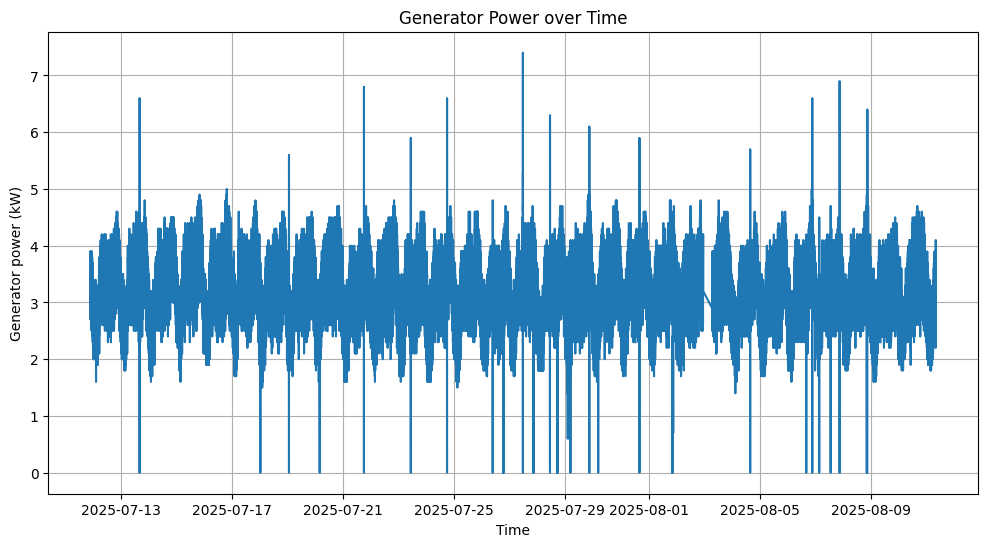

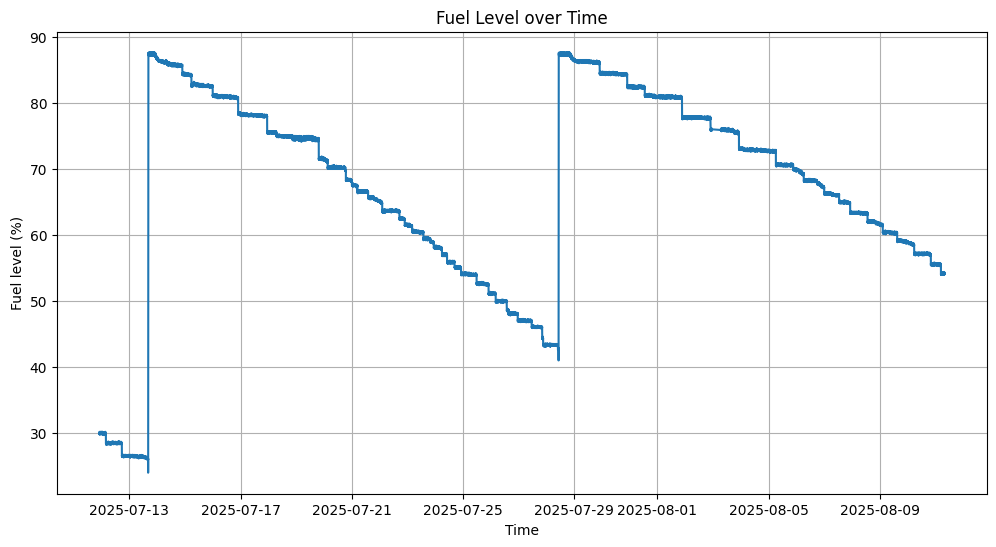

In [19]:
plt.figure(figsize=(12, 6))
plt.plot(site['refresh_time'], site['Generator power (kW)'])
plt.xlabel('Time')
plt.ylabel('Generator power (kW)')
plt.title('Generator Power over Time')
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(site['refresh_time'], site['Fuel level (%)'])
plt.xlabel('Time')
plt.ylabel('Fuel level (%)')
plt.title('Fuel Level over Time')
plt.grid(True)
plt.show()

In [20]:
site['Fuel level change'] = site['Fuel level (%)'].diff()

refueling_events = site[site['Fuel level change'] > 5] # Assuming a change of more than 5% indicates refueling

print("Refueling Events:")
display(refueling_events[['refresh_time', 'Fuel level (%)', 'Fuel level change']])

Refueling Events:


,refresh_time,Fuel level (%),Fuel level change
2538,2025-07-13 16:17:23,34.8,8.9
2539,2025-07-13 16:18:23,43.7,8.9
2540,2025-07-13 16:19:23,52.6,8.9
2541,2025-07-13 16:20:23,61.1,8.5
2542,2025-07-13 16:21:23,68.9,7.8
2543,2025-07-13 16:22:23,75.8,6.9
2544,2025-07-13 16:23:23,81.2,5.4
2545,2025-07-13 16:24:23,87.2,6.0
23617,2025-07-28 10:37:23,52.2,11.2
23618,2025-07-28 10:38:23,62.3,10.1


In [21]:
# Calculate the time difference between consecutive refueling events
refueling_events['time_diff'] = refueling_events['refresh_time'].diff().dt.total_seconds() / 3600 # in hours

# Calculate the fuel consumed between consecutive refueling events
refueling_events['fuel_consumed'] = -refueling_events['Fuel level change'] # Fuel change is positive for refueling, so consumed is negative of that

# Calculate fuel consumption rate (Fuel consumed per hour)
refueling_events['consumption_rate'] = refueling_events['fuel_consumed'] / refueling_events['time_diff']

print("Fuel Consumption Rate between Refueling Events:")
display(refueling_events[['refresh_time', 'Fuel level (%)', 'Fuel level change', 'time_diff', 'fuel_consumed', 'consumption_rate']].dropna())

Fuel Consumption Rate between Refueling Events:


/tmp/ipython-input-2961970212.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  refueling_events['time_diff'] = refueling_events['refresh_time'].diff().dt.total_seconds() / 3600 # in hours
/tmp/ipython-input-2961970212.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  refueling_events['fuel_consumed'] = -refueling_events['Fuel level change'] # Fuel change is positive for refueling, so consumed is negative of that
/tmp/ipython-input-2961970212.py:8: SettingWithCopyWarning: 
A value is trying to be set on

,refresh_time,Fuel level (%),Fuel level change,time_diff,fuel_consumed,consumption_rate
2539,2025-07-13 16:18:23,43.7,8.9,0.016667,-8.9,-534.0
2540,2025-07-13 16:19:23,52.6,8.9,0.016667,-8.9,-534.0
2541,2025-07-13 16:20:23,61.1,8.5,0.016667,-8.5,-510.0
2542,2025-07-13 16:21:23,68.9,7.8,0.016667,-7.8,-468.0
2543,2025-07-13 16:22:23,75.8,6.9,0.016667,-6.9,-414.0
2544,2025-07-13 16:23:23,81.2,5.4,0.016667,-5.4,-324.0
2545,2025-07-13 16:24:23,87.2,6.0,0.016667,-6.0,-360.0
23617,2025-07-28 10:37:23,52.2,11.2,354.216667,-11.2,-0.031619
23618,2025-07-28 10:38:23,62.3,10.1,0.016667,-10.1,-606.0
23619,2025-07-28 10:39:23,70.5,8.2,0.016667,-8.2,-492.0


In [22]:
# Identify the indices of refueling events
refueling_indices = refueling_events.index

# Initialize lists to store results
consumption_rates_between_refuels = []
start_times = []
end_times = []
fuel_consumed_between = []
time_diffs_between = []

# Iterate through the periods between refueling events
for i in range(len(refueling_indices) - 1):
    start_index = refueling_indices[i]
    end_index = refueling_indices[i+1]

    # Select the data between the two refueling events
    period_data = site.loc[start_index:end_index]

    # Calculate the fuel level change during this period (should be negative)
    fuel_change = period_data['Fuel level (%)'].iloc[-1] - period_data['Fuel level (%)'].iloc[0]

    # Calculate the time difference in hours
    time_diff = (period_data['refresh_time'].iloc[-1] - period_data['refresh_time'].iloc[0]).total_seconds() / 3600

    # Calculate consumption rate if time difference is not zero and fuel change is negative
    if time_diff > 0 and fuel_change < 0:
        consumption_rate = -fuel_change / time_diff  # Consumption rate should be positive

        start_times.append(period_data['refresh_time'].iloc[0])
        end_times.append(period_data['refresh_time'].iloc[-1])
        fuel_consumed_between.append(-fuel_change)
        time_diffs_between.append(time_diff)
        consumption_rates_between_refuels.append(consumption_rate)

# Create a DataFrame to display the results
consumption_df = pd.DataFrame({
    'Start Time': start_times,
    'End Time': end_times,
    'Fuel Consumed (%)': fuel_consumed_between,
    'Time Elapsed (hours)': time_diffs_between,
    'Consumption Rate (%/hour)': consumption_rates_between_refuels
})

print("Fuel Consumption Rate Between Refueling Events:")
display(consumption_df)

Fuel Consumption Rate Between Refueling Events:


,Start Time,End Time,Fuel Consumed (%),Time Elapsed (hours),Consumption Rate (%/hour)
0,2025-07-13 16:24:23,2025-07-28 10:37:23,35.0,354.216667,0.09881


In [23]:
# Calculate the average generator power during each period between refueling events
average_power_between_refuels = []

# Iterate through the periods that are included in consumption_df
for index, row in consumption_df.iterrows():
    start_time = row['Start Time']
    end_time = row['End Time']

    # Select the data for the specific period from the original site DataFrame
    period_data = site[(site['refresh_time'] >= start_time) & (site['refresh_time'] <= end_time)]

    # Calculate the average generator power for the period
    average_power = period_data['Generator power (kW)'].mean()
    average_power_between_refuels.append(average_power)

# Add the average power to the consumption_df DataFrame
consumption_df['Average Generator Power (kW)'] = average_power_between_refuels

print("Fuel Consumption Rate and Average Generator Power Between Refueling Events:")
display(consumption_df)

# You can also calculate the correlation between consumption rate and average power
correlation = consumption_df['Consumption Rate (%/hour)'].corr(consumption_df['Average Generator Power (kW)'])
print(f"\nCorrelation between Consumption Rate and Average Generator Power: {correlation}")

Fuel Consumption Rate and Average Generator Power Between Refueling Events:


,Start Time,End Time,Fuel Consumed (%),Time Elapsed (hours),Consumption Rate (%/hour),Average Generator Power (kW)
0,2025-07-13 16:24:23,2025-07-28 10:37:23,35.0,354.216667,0.09881,3.171733



Correlation between Consumption Rate and Average Generator Power: nan


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


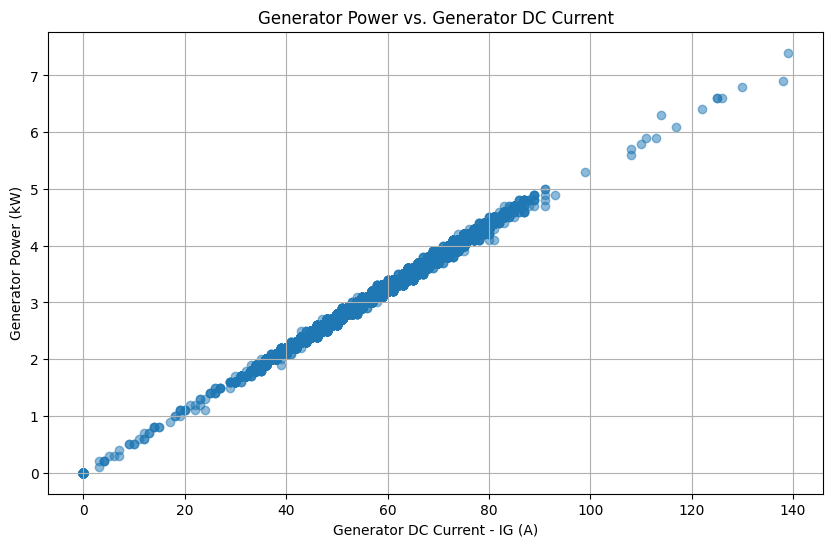

In [24]:
plt.figure(figsize=(10, 6))
plt.scatter(site['Generator DC current - IG (A)'], site['Generator power (kW)'], alpha=0.5)
plt.xlabel('Generator DC Current - IG (A)')
plt.ylabel('Generator Power (kW)')
plt.title('Generator Power vs. Generator DC Current')
plt.grid(True)
plt.show()

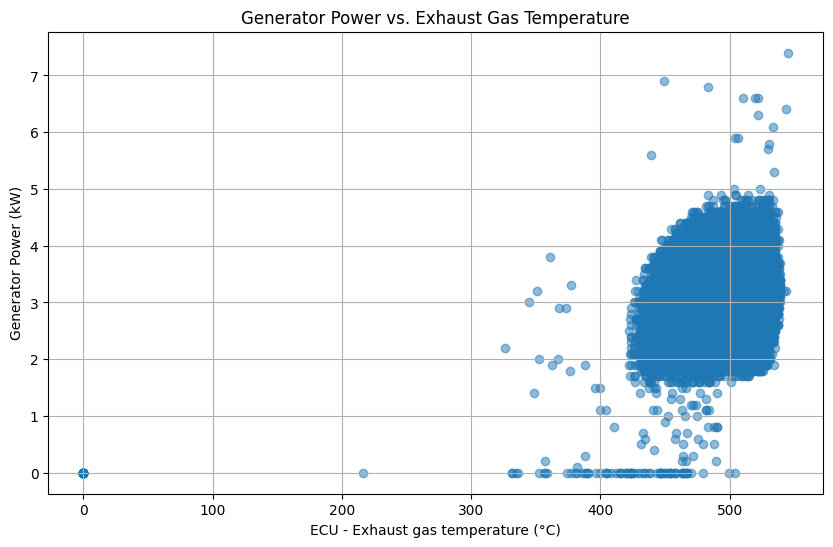

In [25]:
plt.figure(figsize=(10, 6))
plt.scatter(site['ECU - Exhaust gas temperature (°C)'], site['Generator power (kW)'], alpha=0.5)
plt.xlabel('ECU - Exhaust gas temperature (°C)')
plt.ylabel('Generator Power (kW)')
plt.title('Generator Power vs. Exhaust Gas Temperature')
plt.grid(True)
plt.show()

Data within the exhaust temperature cluster (450°C - 520°C):


,refresh_time
count,36759
mean,2025-07-26 15:11:07.984901888
min,2025-07-11 21:58:23
25%,2025-07-18 22:08:53
50%,2025-07-25 16:54:23
75%,2025-08-03 15:16:53
max,2025-08-11 07:54:23


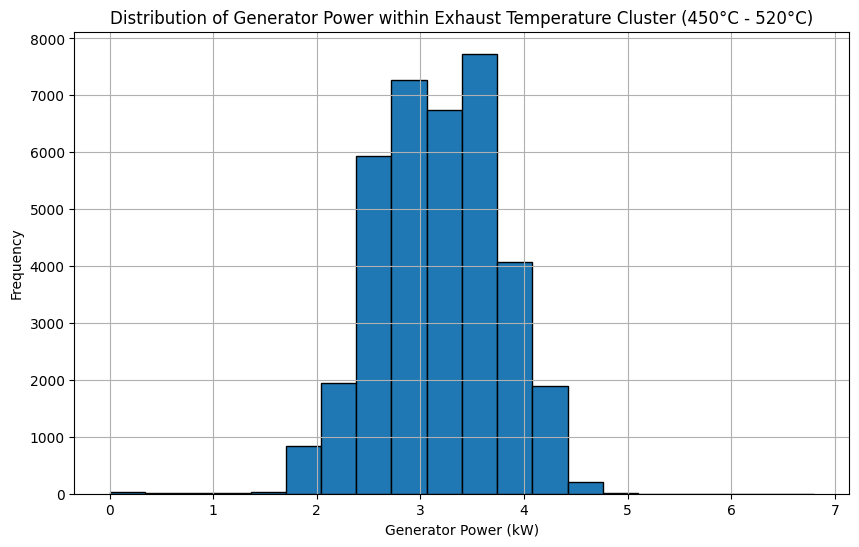

In [26]:
# Filter the data for the specified temperature range
temperature_cluster_data = site[(site['ECU - Exhaust gas temperature (°C)'] >= 450) & (site['ECU - Exhaust gas temperature (°C)'] <= 520)]

print("Data within the exhaust temperature cluster (450°C - 520°C):")
display(temperature_cluster_data.describe())

# Plot a histogram of Generator Power within this cluster
plt.figure(figsize=(10, 6))
plt.hist(temperature_cluster_data['Generator power (kW)'].dropna(), bins=20, edgecolor='black')
plt.xlabel('Generator Power (kW)')
plt.ylabel('Frequency')
plt.title('Distribution of Generator Power within Exhaust Temperature Cluster (450°C - 520°C)')
plt.grid(True)
plt.show()

Data within the exhaust temperature cluster (200°C - 430°C):


,refresh_time
count,112
mean,2025-07-24 21:48:34.785714432
min,2025-07-13 16:25:23
25%,2025-07-16 02:41:53
50%,2025-07-28 16:51:53
75%,2025-07-28 17:19:38
max,2025-08-08 20:44:23


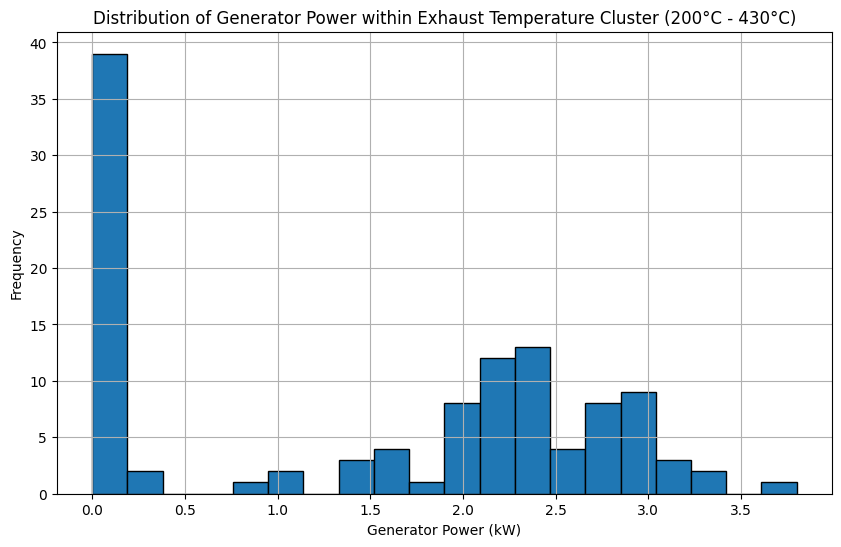

In [27]:
# Filter the data for the specified temperature range
temperature_cluster_data_200_430 = site[(site['ECU - Exhaust gas temperature (°C)'] >= 200) & (site['ECU - Exhaust gas temperature (°C)'] <= 430)]

print("Data within the exhaust temperature cluster (200°C - 430°C):")
display(temperature_cluster_data_200_430.describe())

# Plot a histogram of Generator Power within this cluster
plt.figure(figsize=(10, 6))
plt.hist(temperature_cluster_data_200_430['Generator power (kW)'].dropna(), bins=20, edgecolor='black')
plt.xlabel('Generator Power (kW)')
plt.ylabel('Frequency')
plt.title('Distribution of Generator Power within Exhaust Temperature Cluster (200°C - 430°C)')
plt.grid(True)
plt.show()

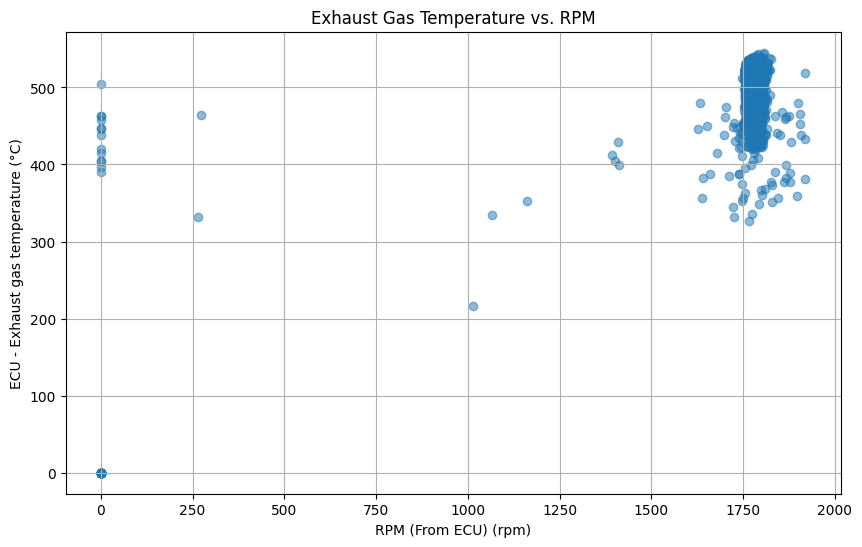

In [28]:
plt.figure(figsize=(10, 6))
plt.scatter(site['RPM (From ECU) (rpm)'], site['ECU - Exhaust gas temperature (°C)'], alpha=0.5)
plt.xlabel('RPM (From ECU) (rpm)')
plt.ylabel('ECU - Exhaust gas temperature (°C)')
plt.title('Exhaust Gas Temperature vs. RPM')
plt.grid(True)
plt.show()

In [29]:
# Separate data into high and low RPM groups
high_rpm_data = site[site['RPM (From ECU) (rpm)'] > 1500]
low_rpm_data = site[site['RPM (From ECU) (rpm)'] <= 1500]

print("Descriptive Statistics for High RPM Data (RPM > 1500):")
display(high_rpm_data.describe())

print("\nDescriptive Statistics for Low RPM Data (RPM <= 1500):")
display(low_rpm_data.describe())

Descriptive Statistics for High RPM Data (RPM > 1500):


,refresh_time
count,42756
mean,2025-07-27 01:08:22.987369984
min,2025-07-11 21:58:23
25%,2025-07-19 11:20:08
50%,2025-07-26 22:33:53
75%,2025-08-03 19:39:38
max,2025-08-11 07:54:23



Descriptive Statistics for Low RPM Data (RPM <= 1500):


,refresh_time
count,47
mean,2025-07-29 01:54:49.808510720
min,2025-07-13 16:25:23
25%,2025-07-24 02:11:23
50%,2025-07-28 10:44:23
75%,2025-08-04 15:34:53
max,2025-08-08 20:44:23


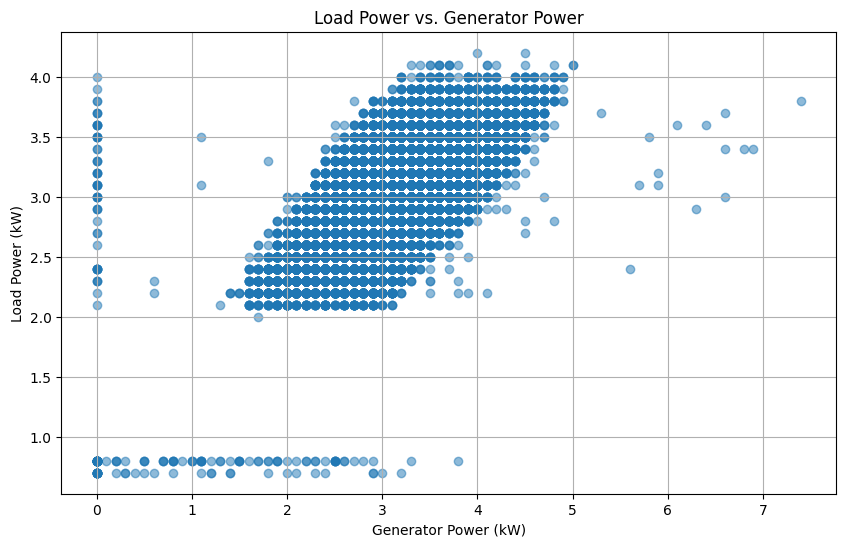

In [30]:
plt.figure(figsize=(10, 6))
plt.scatter(site['Generator power (kW)'], site['Load power (kW)'], alpha=0.5)
plt.xlabel('Generator Power (kW)')
plt.ylabel('Load Power (kW)')
plt.title('Load Power vs. Generator Power')
plt.grid(True)
plt.show()

In [32]:
# Inspect data points where generator power is close to 0
zero_power_data = site[site['Generator power (kW)'] < 0.1]
print("Data points where Generator Power is close to 0 kW:")
display(zero_power_data.describe())

Data points where Generator Power is close to 0 kW:


,refresh_time
count,98
mean,2025-07-29 07:51:43.204081920
min,2025-07-13 16:25:23
25%,2025-07-26 18:29:38
50%,2025-07-28 13:47:53
75%,2025-08-01 13:11:08
max,2025-08-08 20:43:23


Data points where Generator Power is between 0.1 kW and 2.0 kW:


,refresh_time
count,1112
mean,2025-07-27 12:09:30.553956864
min,2025-07-12 00:42:23
25%,2025-07-21 04:03:53
50%,2025-07-27 02:58:23
75%,2025-08-02 03:31:38
max,2025-08-11 05:15:23


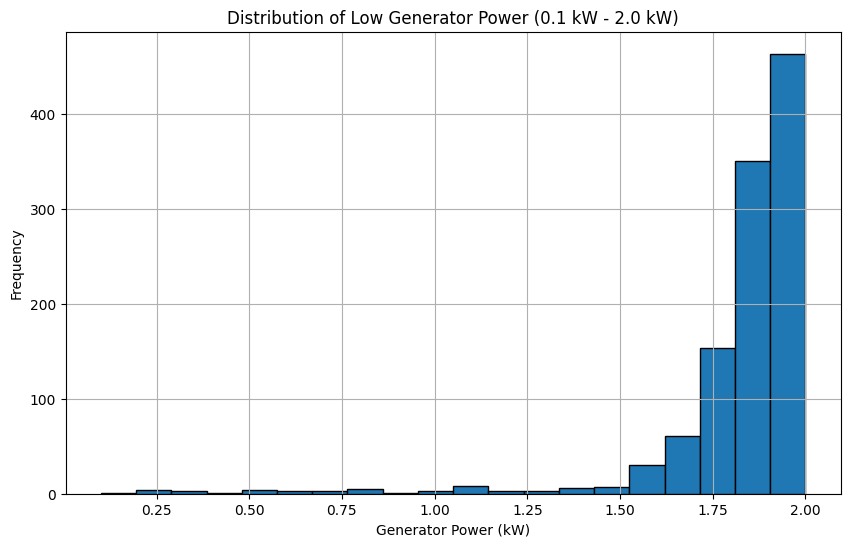

In [33]:
# Filter data for low generator power (between 0.1 and 2.0 kW)
low_generator_power_data = site[(site['Generator power (kW)'] >= 0.1) & (site['Generator power (kW)'] <= 2.0)]

print("Data points where Generator Power is between 0.1 kW and 2.0 kW:")
display(low_generator_power_data.describe())

# Optionally, you could also plot a histogram for this subset
plt.figure(figsize=(10, 6))
plt.hist(low_generator_power_data['Generator power (kW)'].dropna(), bins=20, edgecolor='black')
plt.xlabel('Generator Power (kW)')
plt.ylabel('Frequency')
plt.title('Distribution of Low Generator Power (0.1 kW - 2.0 kW)')
plt.grid(True)
plt.show()

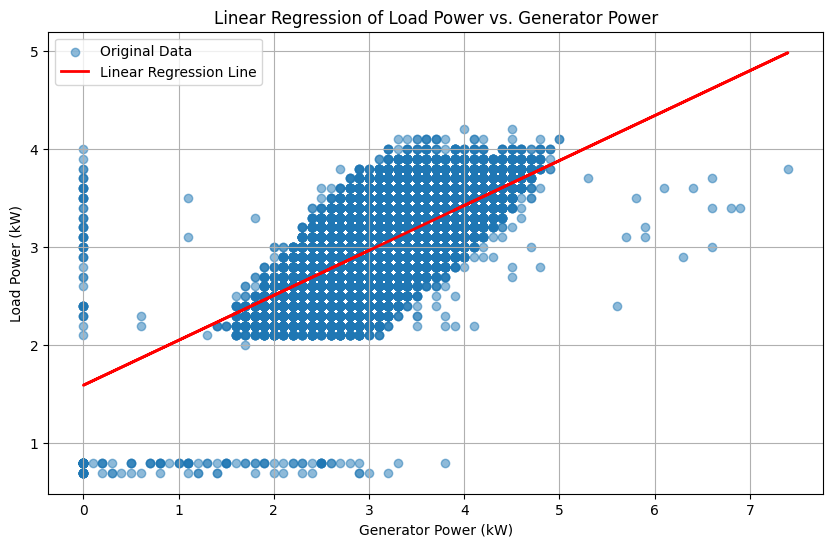

Intercept: 1.59
Coefficient: 0.46


In [35]:
from sklearn.linear_model import LinearRegression

# Prepare the data for linear regression
# We need to reshape the data to be a 2D array for scikit-learn

# Drop rows with NaN values in the relevant columns
cleaned_site = site.dropna(subset=['Generator power (kW)', 'Load power (kW)'])

X = cleaned_site['Generator power (kW)'].values.reshape(-1, 1)
y = cleaned_site['Load power (kW)'].values.reshape(-1, 1)


# Create and fit the linear regression model
model = LinearRegression()
model.fit(X, y)

# Make predictions
y_pred = model.predict(X)

# Plot the original data and the regression line
plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.5, label='Original Data')
plt.plot(X, y_pred, color='red', linewidth=2, label='Linear Regression Line')
plt.xlabel('Generator Power (kW)')
plt.ylabel('Load Power (kW)')
plt.title('Linear Regression of Load Power vs. Generator Power')
plt.grid(True)
plt.legend()
plt.show()

# Print the coefficients
print(f"Intercept: {model.intercept_[0]:.2f}")
print(f"Coefficient: {model.coef_[0][0]:.2f}")

Certainly! Here's an interpretation of the linear regression results for Generator Power vs. Load Power:

**The** **scatter** **plot**: The plot shows a strong positive linear relationship between generator power and load power when the generator is operating (the cluster of points that is not near 0,0). As the generator power increases, the load power also tends to increase. The points clustered near (0,0) likely represent times when the generator is not actively supplying power.

**The** **intercept** (**1.59**): The intercept represents the estimated load power when the generator power is 0 kW. In a perfect scenario with a generator supplying the entire load, you might expect this to be close to zero. However, the non-zero intercept suggests that there might be a base load being met from another source when the generator is off, or it could be influenced by the data points where the generator is running at very low power.

**The** **coefficient** (**0.46**): The coefficient represents the estimated change in load power for every 1 kW increase in generator power. A coefficient of 0.46 suggests that for every additional kW of power generated, the load power increases by approximately 0.46 kW. This indicates that the generator is contributing to the load, but there might be some power losses, or the generator is not always solely responsible for the entire load, or there are other power sources contributing to the load.

In summary, the linear regression confirms a positive relationship between generator and load power during operation, but the intercept and coefficient values suggest a more complex power distribution system where the generator might not be the sole power source, or there are system losses.

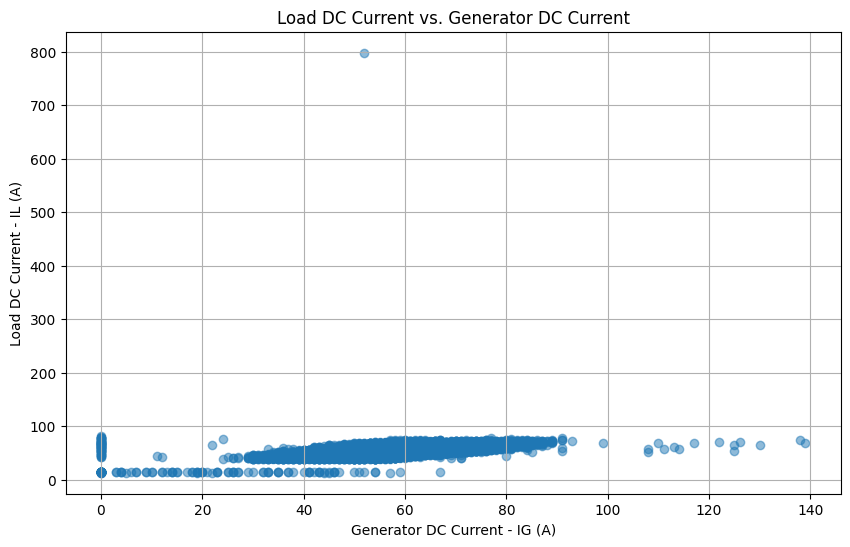

In [36]:
plt.figure(figsize=(10, 6))
plt.scatter(site['Generator DC current - IG (A)'], site['Load DC current - IL (A)'], alpha=0.5)
plt.xlabel('Generator DC Current - IG (A)')
plt.ylabel('Load DC Current - IL (A)')
plt.title('Load DC Current vs. Generator DC Current')
plt.grid(True)
plt.show()

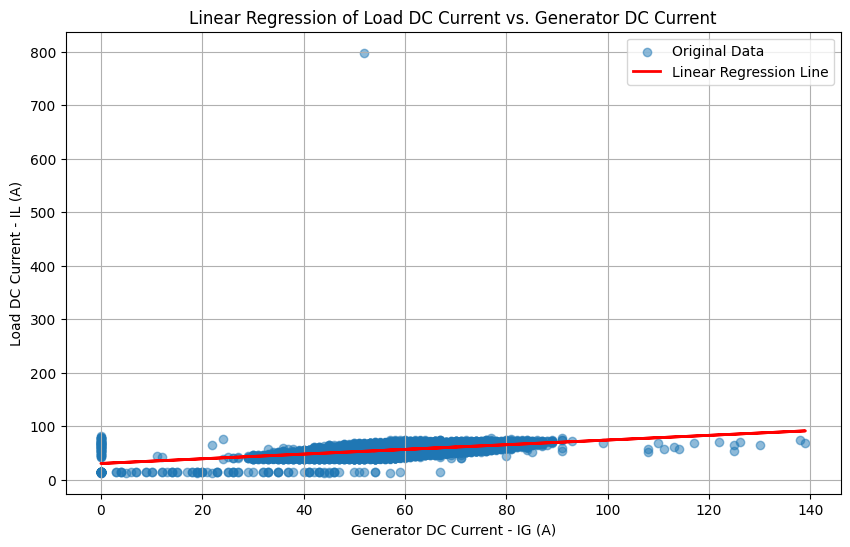

Intercept: 30.28
Coefficient: 0.44


In [37]:
from sklearn.linear_model import LinearRegression

# Prepare the data for linear regression on current
# Drop rows with NaN values in the relevant columns
cleaned_site_current = site.dropna(subset=['Generator DC current - IG (A)', 'Load DC current - IL (A)'])

X_current = cleaned_site_current['Generator DC current - IG (A)'].values.reshape(-1, 1)
y_current = cleaned_site_current['Load DC current - IL (A)'].values.reshape(-1, 1)

# Create and fit the linear regression model
model_current = LinearRegression()
model_current.fit(X_current, y_current)

# Make predictions
y_pred_current = model_current.predict(X_current)

# Plot the original data and the regression line
plt.figure(figsize=(10, 6))
plt.scatter(X_current, y_current, alpha=0.5, label='Original Data')
plt.plot(X_current, y_pred_current, color='red', linewidth=2, label='Linear Regression Line')
plt.xlabel('Generator DC Current - IG (A)')
plt.ylabel('Load DC Current - IL (A)')
plt.title('Linear Regression of Load DC Current vs. Generator DC Current')
plt.grid(True)
plt.legend()
plt.show()

# Print the coefficients
print(f"Intercept: {model_current.intercept_[0]:.2f}")
print(f"Coefficient: {model_current.coef_[0][0]:.2f}")

Now, let's compare the relationships we found for both power and current.

Both the power and current analyses show a positive linear relationship between the generator and load when the generator is operating.

**Power** **Analysis**: Intercept: 1.59 kW, Coefficient: 0.46. This suggests a base load of around 1.59 kW when the generator power is zero, and for every 1 kW increase in generator power, the load power increases by approximately 0.46 kW.

**Current** **Analysis**: Intercept: 30.28 A, Coefficient: 0.44. This suggests a base load current of around 30.28 A when the generator current is zero, and for every 1 A increase in generator current, the load current increases by approximately 0.44 A.

The coefficients in both analyses (0.46 for power and 0.44 for current) are relatively close, suggesting a consistent linear relationship between the generator's output and the load's demand in terms of both power and current when the generator is active. The non-zero intercepts in both cases further support the idea of a base load potentially being supplied by another source or system losses.


Identified 127 outliers based on a residual threshold of 20.45:


,refresh_time,Generator DC voltage (V),Generator DC current - IG (A),Load DC current - IL (A),Generator power (kW),Load power (kW),RPM (From ECU) (rpm),Work hours (h),ECU - Exhaust gas temperature (°C),Fuel level (%),Service hours (h),Expansion board inputs status,Oil pressure (bar),Fuel level change
2546,2025-07-13 16:25:23,51.0,0.0,62.0,0.0,3.4,1160.0,27407.0,352.5,87.2,3017.0,0.0,0.0,0.0
2547,2025-07-13 16:26:23,55.2,125.0,53.0,6.6,3.0,1918.0,27407.0,519.2,87.1,3017.0,0.0,0.0,-0.1
3971,2025-07-14 16:10:23,53.2,52.0,798.0,2.9,3.5,1790.0,27430.0,471.4,85.7,2994.0,0.0,0.0,0.0
8690,2025-07-18 00:41:23,48.7,0.0,53.0,0.0,2.3,0.0,27510.0,0.0,75.5,2914.0,0.0,0.0,0.0
8691,2025-07-18 00:42:23,12.7,0.0,53.0,0.0,2.7,0.0,27510.0,390.0,75.7,2914.0,0.0,0.0,0.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38007,2025-08-07 20:46:23,9.5,0.0,73.0,0.0,3.5,0.0,28006.0,446.4,65.0,2418.0,0.0,0.0,0.0
39398,2025-08-08 20:14:23,49.6,0.0,80.0,0.0,4.0,1782.0,28030.0,443.5,61.8,2394.0,0.0,0.0,0.0
39426,2025-08-08 20:42:23,48.0,0.0,77.0,0.0,3.6,0.0,28030.0,0.0,61.8,2394.0,0.0,0.0,NaN
39427,2025-08-08 20:43:23,8.6,0.0,81.0,0.0,3.9,0.0,28030.0,447.1,61.7,2394.0,0.0,0.0,-0.1


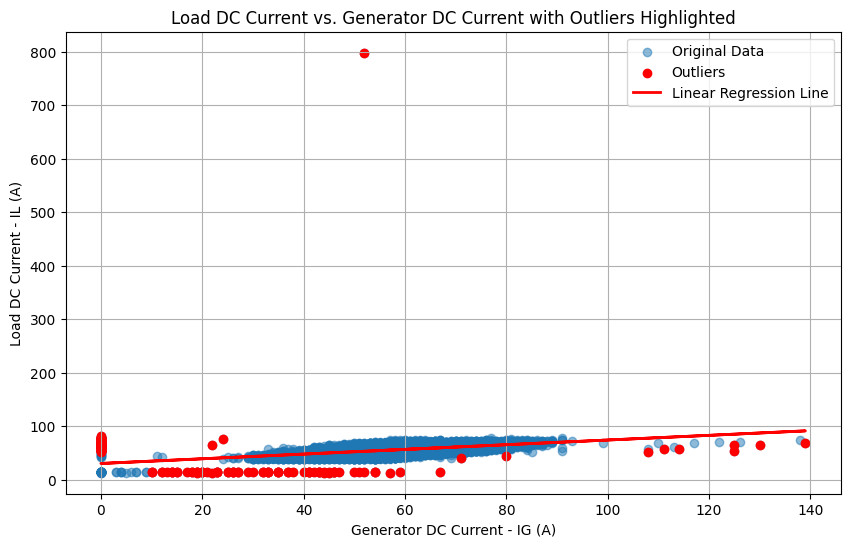

In [38]:
# Calculate the residuals (the difference between the actual and predicted load current)
residuals = cleaned_site_current['Load DC current - IL (A)'] - y_pred_current.flatten()

# Define a threshold for identifying outliers (e.g., based on standard deviation of residuals)
# A common approach is to use a multiple of the standard deviation
threshold = 3 * np.std(residuals)

# Identify outliers
outlier_indices = cleaned_site_current[np.abs(residuals) > threshold].index
outliers = cleaned_site_current.loc[outlier_indices]

print(f"Identified {len(outliers)} outliers based on a residual threshold of {threshold:.2f}:")
display(outliers)

# Optionally, plot the outliers on the scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(cleaned_site_current['Generator DC current - IG (A)'], cleaned_site_current['Load DC current - IL (A)'], alpha=0.5, label='Original Data')
plt.scatter(outliers['Generator DC current - IG (A)'], outliers['Load DC current - IL (A)'], color='red', label='Outliers')
plt.plot(X_current, y_pred_current, color='red', linewidth=2, label='Linear Regression Line')
plt.xlabel('Generator DC Current - IG (A)')
plt.ylabel('Load DC Current - IL (A)')
plt.title('Load DC Current vs. Generator DC Current with Outliers Highlighted')
plt.grid(True)
plt.legend()
plt.show()

In [39]:
# Check unique values in 'Expansion board inputs status'
print("Unique values in 'Expansion board inputs status':")
display(site['Expansion board inputs status'].unique())

# Get the value counts for each unique value
print("\nValue counts for 'Expansion board inputs status':")
display(site['Expansion board inputs status'].value_counts())

# You can then group the data by this column to analyze other parameters in each state
# For example, to see the average generator power in each state:
print("\nAverage Generator Power (kW) for each Expansion board inputs status:")
display(site.groupby('Expansion board inputs status')['Generator power (kW)'].mean())

Unique values in 'Expansion board inputs status':


array([0.0, nan], dtype=object)


Value counts for 'Expansion board inputs status':


,count
Expansion board inputs status,
0.0,42833



Average Generator Power (kW) for each Expansion board inputs status:


,Generator power (kW)
Expansion board inputs status,
0.0,3.161145
